<a href="https://colab.research.google.com/github/FRosty799/img_rep_1237050045/blob/main/Copy_of_modul_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opencv-python

# Instalasi dan Inisiasi Package di Python

In [3]:
# Mengimport library OpenCV
import cv2

# Mengimport cv2_imshow untuk menampilkan image di Jupyter Lab
# cv2_imshow merupakan perbaikan dari cv2.imshow
# yang tidak dapat digunakan di Google Colab
from google.colab.patches import cv2_imshow

# Mengimport numpy, library untuk pemrosesan numerik berbasis matriks
import numpy as np

# Mengimport random, library untuk membuat nilai angka secara acak
import random

# Mengakses Image

## Membaca image

In [4]:
# Membaca image dari file dino.png
# representasi dari image tersebut disimpan di variabel image_dino
# Download terlebih dahulu contoh image dari
# https://gitlab.com/marchgis/march-ed/2023/courses/if216006-praktikum-sistem-multimedia/-/raw/main/modul-2/dino.png
# Lalu upload ke folder sample_data di Google Drive
alamat_image = '/content/sample_data/dino.png'

image_dino = cv2.imread(alamat_image)

# nama_image.shape berisi tuple dimensi (tinggi, lebar, jumlah_channel)
dimensi = image_dino.shape
tinggi = dimensi[0]
lebar = dimensi[1]
jumlah_channel = dimensi[2]

print("Image {} tingginya {} lebarnya {}".format(alamat_image, tinggi, lebar))


AttributeError: 'NoneType' object has no attribute 'shape'

## Membaca kode warna Blue, Green, Red (BGR) dari image

In [ ]:
# Mengambil nilai B, G, R satu pixel pada lokasi 7,0
baris_ke = 7
kolom_ke = 0
(B, G, R) = image_dino[baris_ke, kolom_ke]
print(B, G, R)

## Menampilkan image di Google Colab

In [ ]:
cv2_imshow(image_dino)

# Manipulasi Bentuk, Posisi dan Ukuran Image

## Memotong Gambar / Cropping

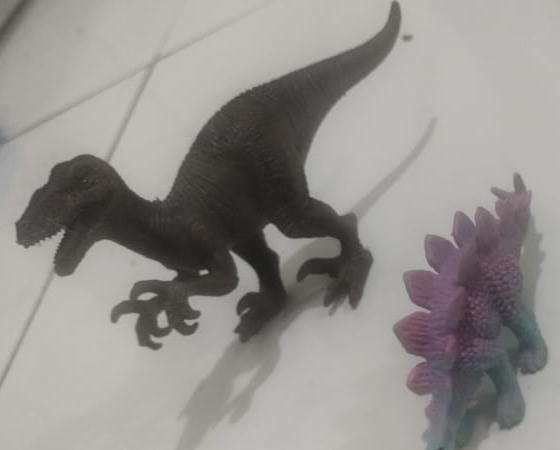

In [ ]:
x1 = 140
y1 = 0
x2 = 700
y2 = 450
image_dino_crop = image_dino[y1:y2, x1:x2]
cv2_imshow(image_dino_crop)

## Mengubah Ukuran / Resize dengan Skala

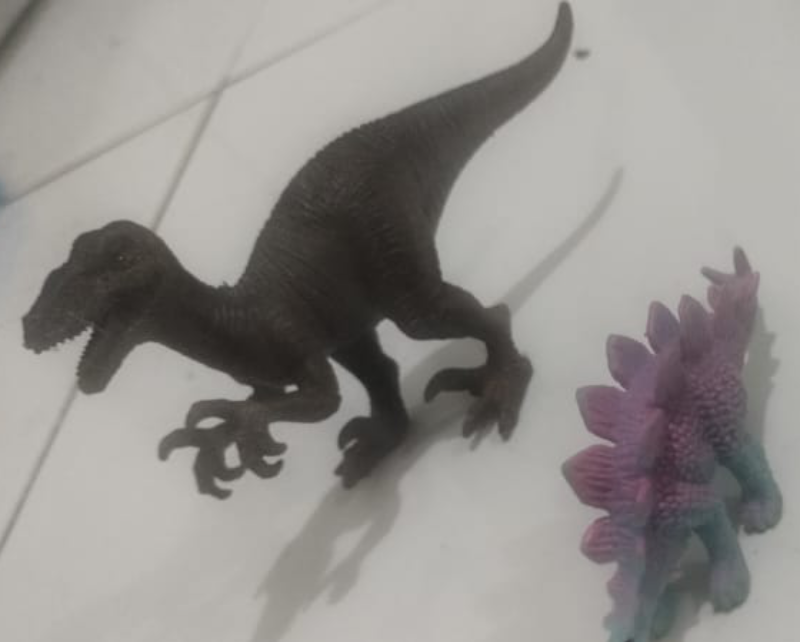

In [ ]:
minimum_lebar = 800
minimum_tinggi = 1500

skala_lebar = minimum_lebar / image_dino_crop.shape[1]
skala_tinggi = minimum_tinggi / image_dino_crop.shape[0]
skala = min(skala_lebar, skala_tinggi) # Skala perubahan ukuran

dimensi_image_resize = (int(image_dino_crop.shape[1] * skala), int(image_dino_crop.shape[0] * skala))

image_dino_resize = cv2.resize(
  image_dino_crop,
  dimensi_image_resize
)
cv2_imshow(image_dino_resize)

## Merotasikan Image

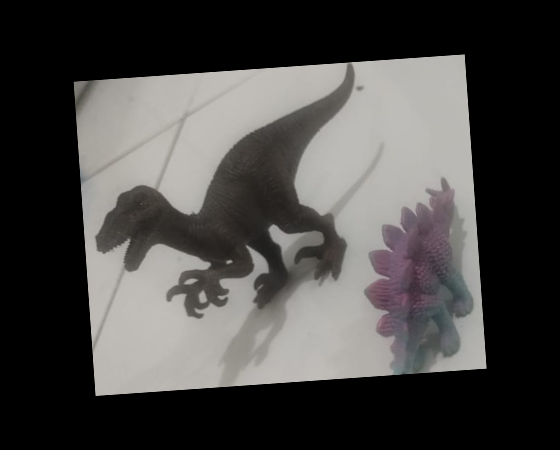

In [ ]:
panjang_image = image_dino_crop.shape[1]
tinggi_image = image_dino_crop.shape[0]

# Sudut rotasi menggunakan fungsi random
# agar bisa merotasi secara acak pada rentang yang ditentukan
# Rotasi acak umum digunakan pada proses image preprocessing maching learning
# Untuk rotasi dengan sudut spesifik, samakan rentang_sudut_rotasi nya
# Sudut rotasi berlawanan jarum jam
rentang_sudut_rotasi = (-35, 35)
sudut_rotasi = random.randint(
  rentang_sudut_rotasi[0],
  rentang_sudut_rotasi[1]
)
skala = 0.7

# Matriks untuk menjalankan transformasi Affine (transformasi linear dan translasi)
# https://docs.opencv.org/3.4/d4/d61/tutorial_warp_affine.html
matriks_rotasi = cv2.getRotationMatrix2D(
    (panjang_image/2,tinggi_image/2),
    sudut_rotasi,
    skala
    )

image_dino_rotasi = cv2.warpAffine(image_dino_crop, matriks_rotasi,(panjang_image,tinggi_image))
cv2_imshow(image_dino_rotasi)

## Memutarbalikkan Image

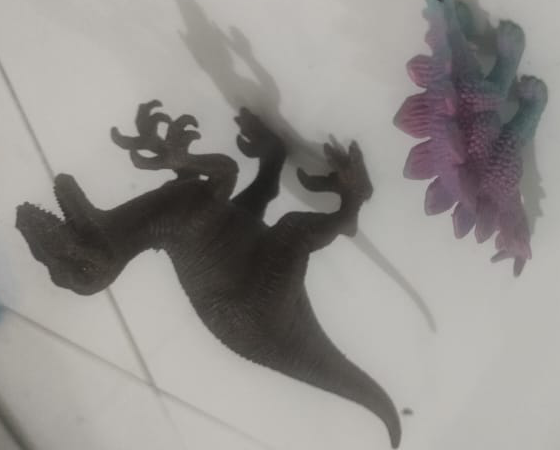

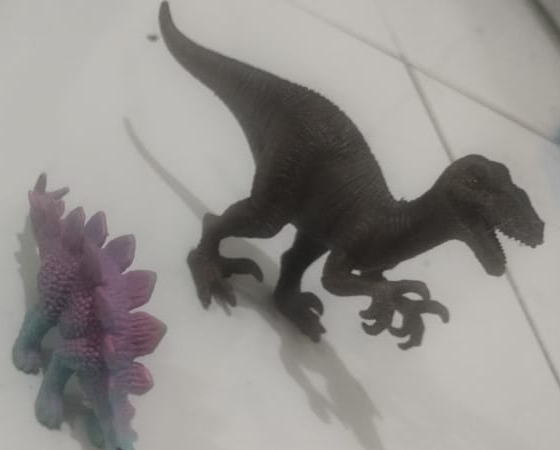

In [ ]:
# flipCode 0 balik vertikal
image_dino_balik_vertikal = cv2.flip(image_dino_crop, flipCode=0)

# flipCode 1 balik horizontal
image_dino_balik_horizontal = cv2.flip(image_dino_crop, flipCode=1)

# flipCode -1 balik vertikal horizontal
image_dino_balik_vertikal_horizontal = cv2.flip(image_dino_crop, flipCode=-1)

cv2_imshow(image_dino_balik_vertikal)
cv2_imshow(image_dino_balik_horizontal)

# Manipulasi Pixel pada Image dengan Filter, Fungsi Kernel, dan Operator

Fungsi Kernel merupakan fungsi yang mentransformasikan setiap elemen matriks menggunakan matriks transformasi. Pada kasus image processing / pemrosesan image, image merupakan bentuk matriks.

## Efek Blur

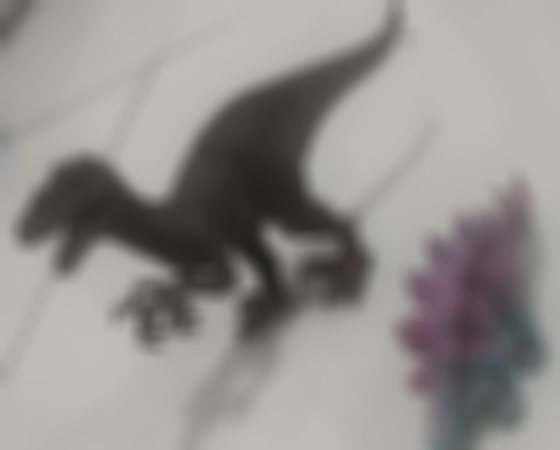

In [ ]:
tingkatan_blur = 20
image_dino_blur = cv2.blur(image_dino_crop, (tingkatan_blur, tingkatan_blur))
cv2_imshow(image_dino_blur)

## Efek Noise

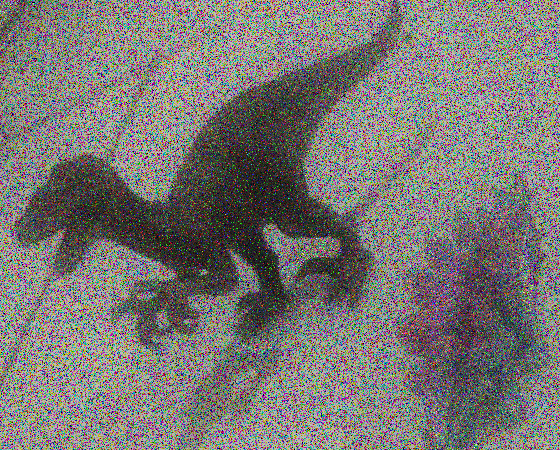

In [ ]:
noise_gauss = np.random.normal(0,1,image_dino_crop.size)
noise_gauss = noise_gauss.reshape(image_dino_crop.shape[0],image_dino_crop.shape[1],image_dino_crop.shape[2]).astype('uint8')
image_dino_noise = image_dino_crop + image_dino_crop * noise_gauss

cv2_imshow(image_dino_noise)

## Efek Brightness dan Contrast

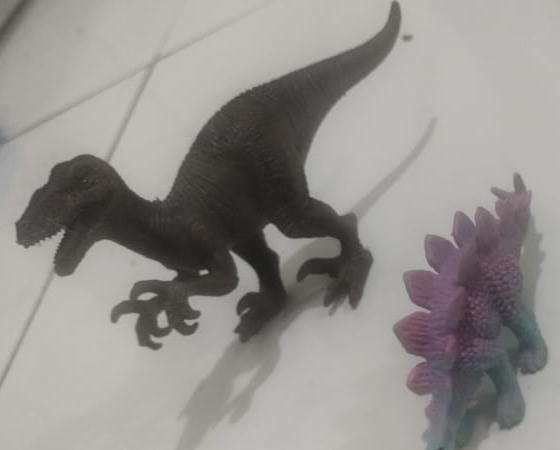

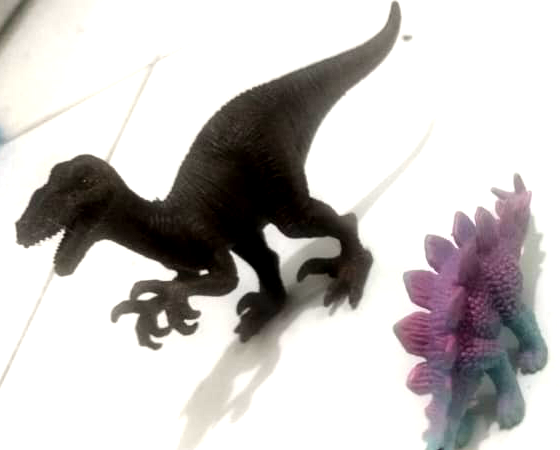

In [ ]:
brightness = 50
contrast = 130
image_dino_brightness_contrast = np.int16(image_dino_crop)
image_dino_brightness_contrast = image_dino_brightness_contrast * (contrast/127+1) - contrast + brightness
image_dino_brightness_contrast = np.clip(image_dino_brightness_contrast, 0, 255)
image_dino_brightness_contrast = np.uint8(image_dino_brightness_contrast)

cv2_imshow(image_dino_crop)
cv2_imshow(image_dino_brightness_contrast)

# Menyimpan Image hasil pemrosesan

In [ ]:
alamat_file_baru = '/content/sample_data/dino_crop.png'

# Method imwrite digunakan untuk menyimpan file
cv2.imwrite(alamat_file_baru, image_dino_crop)

True